In [1]:
%reset -f
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from pyproj import Proj, Transformer
from scipy.interpolate import griddata
import xeofs as xe
from geometry_izzyv1 import grad_sphere
from regression_izzyv1 import linregress_3D
import cartopy.crs as ccrs

crs = ccrs.PlateCarree()
import warnings
import os
from polar_plot_utils import plot_curvilinear_data

warnings.filterwarnings('ignore')
from matplotlib.ticker import MultipleLocator


In [3]:
path = '/Users/iw2g24/PycharmProjects/SSH_project/Data/'
fig_path = '/Users/iw2g24/PycharmProjects/SSH_project/results/NPP_mca/'

ssh_ds = xr.open_dataset(path + 'regridded_ssh2icevel_ds.nc')
wsc_ds = xr.open_dataset(path + 'regridded_wsc2icevel_ds.nc')
oss_ds = xr.open_dataset(path + 'regridded_oss2icevel_ds.nc')
npp_ds = xr.open_dataset(path + 'regridded_to_ice_NPP_ds.nc')
npp_ocean_masked_ds = xr.open_dataset(path + 'regridded_to_ice_ocean_masked_NPP_ds.nc')
npp_shelf_masked_ds = xr.open_dataset(path + 'regridded_to_ice_shelf_masked_NPP_ds.nc')
ice_vel_ds = xr.open_dataset(path + 'ice_vels_no_nan_ds.nc')


In [4]:
#annual data
ice_vels_ds_melt_and_mean = xr.open_dataset(path + 'ice_vels_ds_melt_and_mean.nc')
npp_ocean_ann = xr.open_dataset(path + 'regridded_to_ice_ocean_masked_NPP_ANN_ds.nc')
npp_shelf_ann = xr.open_dataset(path + 'regridded_to_ice_shelf_masked_NPP_ANN_ds.nc')

npp_ocean_ann = npp_ocean_ann.rename({'time':'time_ann'})
npp_shelf_ann = npp_shelf_ann.rename({'time':'time_ann'})
ice_vels_ds_melt_and_mean['time_ann'] = pd.to_datetime(ice_vels_ds_melt_and_mean['time_ann'])


In [5]:
#

In [6]:
new_time = pd.to_datetime(npp_ds.time.values).to_period('M').to_timestamp()
npp_ds = npp_ds.assign_coords(time=new_time)
npp_ocean_masked_ds = npp_ocean_masked_ds.assign_coords(time=new_time)
npp_shelf_masked_ds = npp_shelf_masked_ds.assign_coords(time=new_time)

In [7]:
print(new_time.dtype)

datetime64[ns]


In [8]:
print("ssh_ds variables:", list(ssh_ds.data_vars))
print("wsc_ds variables:", list(wsc_ds.data_vars))
print("oss_ds variables:", list(oss_ds.data_vars))
print("npp_ds variables:", list(npp_ds.data_vars))
print("npp ocean masked variables: ", list(npp_ocean_masked_ds.data_vars))
print("npp shelf masked variables: ", list(npp_shelf_masked_ds.data_vars))
print("ice_vel_ds variables:", list(ice_vel_ds.data_vars))
print("npp ocean ann variables:", list(npp_ocean_ann.data_vars))
print("npp shelf ann variables:", list(npp_shelf_ann.data_vars))
print("ice vel mean melt variables: ", list(ice_vels_ds_melt_and_mean.data_vars))

ssh_ds variables: ['SSH_regridded']
wsc_ds variables: ['WSC_regridded']
oss_ds variables: ['OSS_regridded']
npp_ds variables: ['NPP_regridded_to_ice']
npp ocean masked variables:  ['NPP_ocean_masked_regridded_to_ice']
npp shelf masked variables:  ['NPP_shelf_masked_regridded_to_ice']
ice_vel_ds variables: ['melt']
npp ocean ann variables: ['NPP_ocean_masked_regridded_to_ice']
npp shelf ann variables: ['NPP_shelf_masked_regridded_to_ice']
ice vel mean melt variables:  ['melt', 'melt_ann_mean']


In [9]:
print("ssh_ds coords:", ssh_ds.coords)
print("wsc_ds coords:", wsc_ds.coords)
print("oss_ds coords:", oss_ds.coords)
print("npp_ds coords:", npp_ds.coords)
print("npp_ocean_masked_ds coords:", npp_ocean_masked_ds.coords)
print("npp_shelf_masked_ds coords:", npp_shelf_masked_ds.coords)
print("ice_vel_ds coords:", ice_vel_ds.coords)
print("npp ocean ann coords:", npp_ocean_ann.coords)
print("npp shelf ann coords:", npp_shelf_ann.coords)
print("ice vel mean coords:", ice_vels_ds_melt_and_mean.coords)

ssh_ds coords: Coordinates:
  * time     (time) datetime64[ns] 488B 2002-09-01 2002-12-01 ... 2017-09-01
    lat      (y, x) float64 68MB ...
    lon      (y, x) float64 68MB ...
wsc_ds coords: Coordinates:
  * time     (time) datetime64[ns] 488B 2002-09-01 2002-12-01 ... 2017-09-01
    lat      (y, x) float64 68MB ...
    lon      (y, x) float64 68MB ...
oss_ds coords: Coordinates:
  * time     (time) datetime64[ns] 488B 2002-09-01 2002-12-01 ... 2017-09-01
    lat      (y, x) float64 68MB ...
    lon      (y, x) float64 68MB ...
npp_ds coords: Coordinates:
    lat      (y, x) float64 68MB ...
    lon      (y, x) float64 68MB ...
  * time     (time) datetime64[ns] 472B 2003-03-01 2003-06-01 ... 2017-09-01
npp_ocean_masked_ds coords: Coordinates:
    lat      (y, x) float64 68MB ...
    lon      (y, x) float64 68MB ...
  * time     (time) datetime64[ns] 472B 2003-03-01 2003-06-01 ... 2017-09-01
npp_shelf_masked_ds coords: Coordinates:
    lat      (y, x) float64 68MB ...
    lon      (

In [10]:
# For WSC dataset
print("SSH start time:", ssh_ds['SSH_regridded'].time.values[2])
print("SSH end time:", ssh_ds['SSH_regridded'].time.values[-1])

# For WSC dataset
print("WSC start time:", wsc_ds['WSC_regridded'].time.values[2])
print("WSC end time:", wsc_ds['WSC_regridded'].time.values[-1])

# For OSC dataset
print("OSS start time:", oss_ds['OSS_regridded'].time.values[2])
print("OSS end time:", oss_ds['OSS_regridded'].time.values[-1])

# For ice vels dataset
print("ice vel start time:", ice_vel_ds['melt'].time.values[0])
print("ice vel end time:", ice_vel_ds['melt'].time.values[-1])

# For NPP dataset
print("NPP start time:", npp_ds['NPP_regridded_to_ice'].time.values[0])
print("NPP end time:", npp_ds['NPP_regridded_to_ice'].time.values[-1])

# For NPP ocean masked dataset
print("NPP ocean masked start time:", npp_ocean_masked_ds['NPP_ocean_masked_regridded_to_ice'].time.values[0])
print("NPP ocean masked end time:", npp_ocean_masked_ds['NPP_ocean_masked_regridded_to_ice'].time.values[-1])

# For NPP shelf masked dataset
print("NPP shelf masked start time:", npp_shelf_masked_ds['NPP_shelf_masked_regridded_to_ice'].time.values[0])
print("NPP shelf masked end time:", npp_shelf_masked_ds['NPP_shelf_masked_regridded_to_ice'].time.values[-1])


SSH start time: 2003-03-01T00:00:00.000000000
SSH end time: 2017-09-01T00:00:00.000000000
WSC start time: 2003-03-01T00:00:00.000000000
WSC end time: 2017-09-01T00:00:00.000000000
OSS start time: 2003-03-01T00:00:00.000000000
OSS end time: 2017-09-01T00:00:00.000000000
ice vel start time: 2003-03-01T00:00:00.000000000
ice vel end time: 2017-09-01T00:00:00.000000000
NPP start time: 2003-03-01T00:00:00.000000000
NPP end time: 2017-09-01T00:00:00.000000000
NPP ocean masked start time: 2003-03-01T00:00:00.000000000
NPP ocean masked end time: 2017-09-01T00:00:00.000000000
NPP shelf masked start time: 2003-03-01T00:00:00.000000000
NPP shelf masked end time: 2017-09-01T00:00:00.000000000


In [11]:
# Function to flip latitude in a dataset
def flip_lat(ds):
    if 'y' in ds.dims:
        return ds.sel(y=slice(None, None, -1))
    else:
        print('y dimension not found in dataset.')
        return ds

# Apply to each dataset
ssh_ds = flip_lat(ssh_ds)
wsc_ds = flip_lat(wsc_ds)
oss_ds = flip_lat(oss_ds)
npp_ocean_ann = flip_lat(npp_ocean_ann)
npp_shelf_ann = flip_lat(npp_shelf_ann)
#npp_ds = flip_lat(npp_ds)
#ice_vel_ds = flip_lat(ice_vel_ds)


In [12]:
print("SSH latitudes (first 10):", ssh_ds['lat'].values[:2])
print("WSC longitudes (first 10):", wsc_ds['lat'].values[:2])
print("OSS latitudes (first 10):", oss_ds['lat'].values[:2])
print("NPP longitudes (first 10):", npp_ds['lat'].values[:2])
print("ice vel latitudes (first 10):", ice_vel_ds['lat'].values[:2])



SSH latitudes (first 10): [[-54.5936238  -54.60503583 -54.61644464 ... -54.61653376 -54.60512498
  -54.59371297]
 [-54.60503577 -54.61645242 -54.62786585 ... -54.627955   -54.6165416
  -54.60512498]]
WSC longitudes (first 10): [[-54.5936238  -54.60503583 -54.61644464 ... -54.61653376 -54.60512498
  -54.59371297]
 [-54.60503577 -54.61645242 -54.62786585 ... -54.627955   -54.6165416
  -54.60512498]]
OSS latitudes (first 10): [[-54.5936238  -54.60503583 -54.61644464 ... -54.61653376 -54.60512498
  -54.59371297]
 [-54.60503577 -54.61645242 -54.62786585 ... -54.627955   -54.6165416
  -54.60512498]]
NPP longitudes (first 10): [[-54.5936238  -54.60503583 -54.61644464 ... -54.61653376 -54.60512498
  -54.59371297]
 [-54.60503577 -54.61645242 -54.62786585 ... -54.627955   -54.6165416
  -54.60512498]]
ice vel latitudes (first 10): [[-54.5936238  -54.60503583 -54.61644464 ... -54.61653376 -54.60512498
  -54.59371297]
 [-54.60503577 -54.61645242 -54.62786585 ... -54.627955   -54.6165416
  -54.60512

Cumulative sum of squares: [0.51060081 0.90414922 0.99644535 1.        ]
Squared covariance fraction: [0.51060081 0.39354841 0.09229612 0.00355465]
<class 'numpy.ndarray'>
4
PCA fraction [0.5106008098749661, 0.39354841475995606, 0.0922961217177497, 0.003554653647328321]


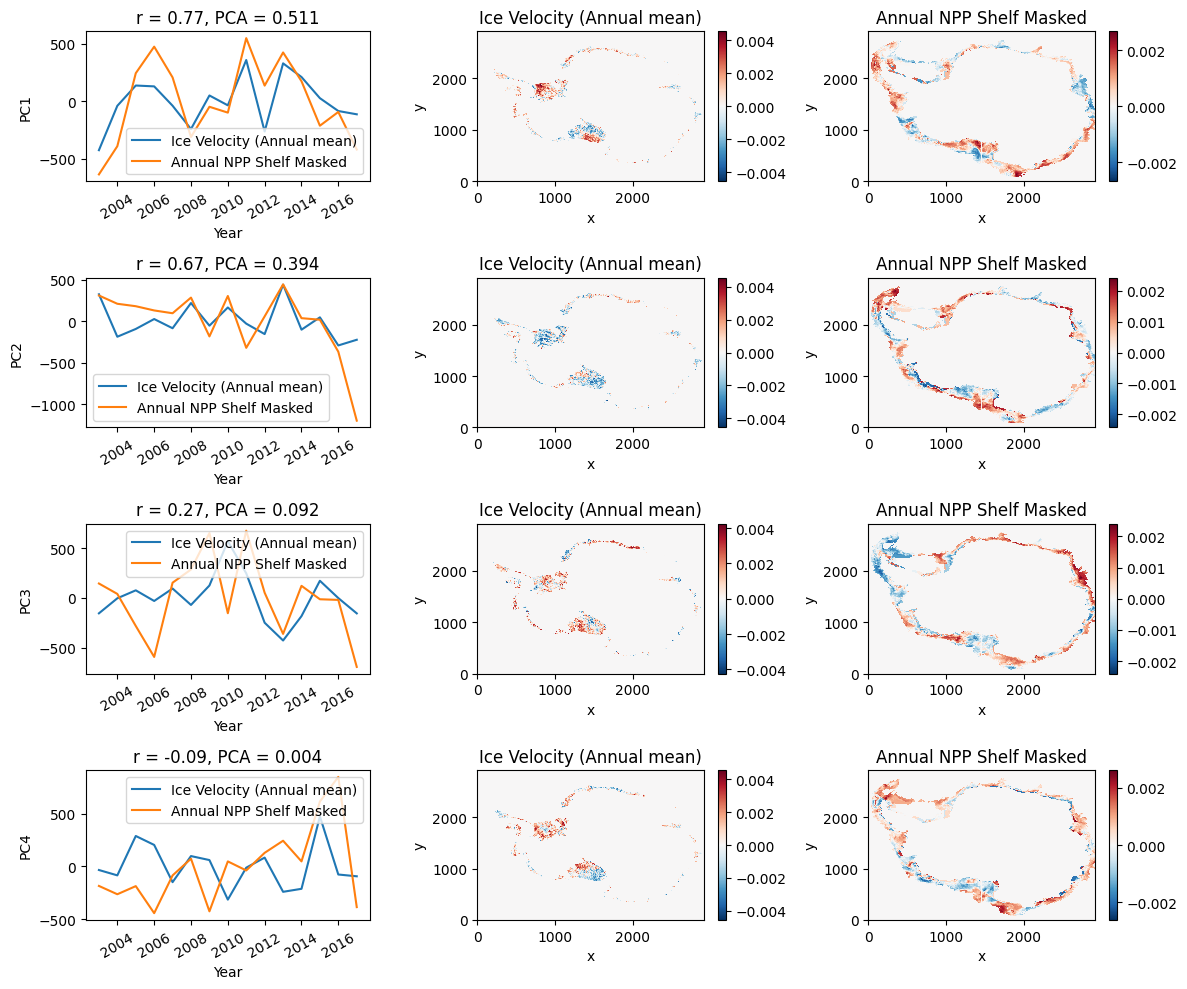

In [13]:
# # model = xe.cross.MCA(n_modes=22, standardize=True) #wsc and ssh
# model = xe.cross.MCA(n_modes=5, standardize=True) # everythign else

model = xe.cross.MCA(n_modes=4, standardize=True) #annual data for ice vel and npp

# sub_ssh_ds = ssh_ds['SSH_regridded'].isel(time=slice(2, None))
# sub_wsc_ds = wsc_ds['WSC_regridded'].isel(time=slice(2, None))
# model.fit(sub_ssh_ds, sub_wsc_ds, dim='time')

# sub_wsc_ds = wsc_ds['WSC_regridded'].isel(time=slice(2, None))
# model.fit(sub_wsc_ds, npp_shelf_masked_ds['NPP_shelf_masked_regridded_to_ice'], dim='time')

# sub_oss_ds = oss_ds['OSS_regridded'].isel(time=slice(2, None))
# model.fit(sub_oss_ds, npp_shelf_masked_ds['NPP_shelf_masked_regridded_to_ice'], dim='time')
#
# sub_ssh_ds = ssh_ds['SSH_regridded'].isel(time=slice(2, None))
# model.fit(sub_ssh_ds, npp_shelf_masked_ds['NPP_shelf_masked_regridded_to_ice'], dim='time')

# model.fit( ice_vel_ds['melt'], npp_shelf_masked_ds['NPP_shelf_masked_regridded_to_ice'], dim='time')

# sub_ssh_ds = ssh_ds['SSH_regridded'].isel(time=slice(2, None))
# model.fit(sub_ssh_ds, ice_vel_ds['melt'], dim='time')

# sub_wsc_ds = wsc_ds['WSC_regridded'].isel(time=slice(2, None))
# model.fit(sub_wsc_ds, ice_vel_ds['melt'], dim='time')

# sub_ocean_ann_ds = npp_ocean_ann['NPP_ocean_masked_regridded_to_ice'].isel(time_ann=slice(0,-7))
# model.fit(ice_vels_ds_melt_and_mean['melt_ann_mean'], sub_ocean_ann_ds, dim='time_ann')

sub_shelf_ann_ds = npp_shelf_ann['NPP_shelf_masked_regridded_to_ice'].isel(time_ann=slice(0,-7))
model.fit(ice_vels_ds_melt_and_mean['melt_ann_mean'], sub_shelf_ann_ds, dim='time_ann')


# #--------- TIME LAG START -------- #
#
# lag = 1  # number of time steps to lag
#
# # Lag SSH forward: keep from time=lag to the end
# lagged_wsc = ssh_ds['SSH_regridded'].isel(time=slice(2, -lag))
#
# # Lag melt backward: keep from time=0 to -lag
# lagged_melt = ice_vel_ds['melt'].isel(time=slice(lag, None))
#
# # Fit MCA model with lagged datasets
# model.fit(lagged_wsc, lagged_melt, dim='time')
#
#
# #---------- TIME LAG END ------ #

comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)
s1 = scores1.values;
s2 = scores2.values
c1 = comps1.values;
c2 = comps2.values

#how can you change from using cross.MCA to calling the subplots PCA1, PCA2, PCA3 etc ...
r_pears = [];
p_pears = []
r_spear = [];
p_spear = []
for m in range(1, 5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2));
    p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2));
    p_spear.append(np.round(p, 2))


sq_cov_frac = model.squared_covariance_fraction()
scf = sq_cov_frac.values
cum_sum = np.cumsum(scf)
print('Cumulative sum of squares:', cum_sum)
print('Squared covariance fraction:', scf)
print(type(cum_sum))
print(len(cum_sum))
mode_percent = []
for i in range(len(cum_sum)):
    if i == 0:
        each_mode_percent = float(cum_sum[i])
        mode_percent.append(each_mode_percent)
    else:
        each_mode_percent = float(cum_sum[i] - cum_sum[i - 1])
        mode_percent.append(each_mode_percent)
print('PCA fraction', mode_percent)


fig = plt.figure(figsize=(12, 10))

for i in range(0, 4):
    j = 3 * i + 1  # a = 2*(i+1) + i - 1

    plt.subplot(4, 3, j)
    scores1.sel(mode=i + 1).plot(label='Ice Velocity (Annual mean)')
    scores2.sel(mode=i + 1).plot(label='Annual NPP Shelf Masked ')
    plt.title("r = {}, PCA = {:.3f}".format(r_spear[i], mode_percent[i]))
    plt.xlabel('Year');
    plt.ylabel('PC' + str(int(i + 1)))
    plt.xticks(rotation=30)
    plt.legend()

    plt.subplot(4, 3, j + 1)
    comps1.sel(mode=i + 1).plot()
    plt.title('Ice Velocity (Annual mean)')

    plt.subplot(4, 3, j + 2)
    comps2.sel(mode=i + 1).plot()
    plt.title('Annual NPP Shelf Masked')

fig.tight_layout()

#fig.savefig(path + 'results/MCA_output_' + gridtype + '_seas.png')
# compute squared covariance fraction (equivalent to explained variance in PCA)
# sq_cov_frac = model.squared_covariance_fraction()
# scf = sq_cov_frac.values
# cum_sum = np.cumsum(scf)
# print('Cumulative sum of squares:', cum_sum)
# print('Squared covariance fraction:', scf)
# print(type(cum_sum))
# print(len(cum_sum))
# mode_percent = []
# for i in range(len(cum_sum)):
#     if i == 0:
#         each_mode_percent = float(cum_sum[i])
#         mode_percent.append(each_mode_percent)
#     else:
#         each_mode_percent = float(cum_sum[i] - cum_sum[i - 1])
#         mode_percent.append(each_mode_percent)
# print('PCA fraction', mode_percent)

In [14]:
# fig = plt.figure(figsize=(12, 10))
#
# for i in range(0, 4):
#     j = 3 * i + 1  # a = 2*(i+1) + i - 1
#
#     plt.subplot(4, 3, j)
#     scores1.sel(mode=i + 1).plot(label='Ice Velocity (Annual mean)')
#     scores2.sel(mode=i + 1).plot(label='NPP Ocean Masked')
#     plt.title("r = {}, PCA = {:.3f}".format(r_spear[i], mode_percent[i]))
#     plt.xlabel('Year');
#     plt.ylabel('PC' + str(int(i + 1)))
#     plt.xticks(rotation=30)
#     plt.legend()
#
#     plt.subplot(4, 3, j + 1)
#     comps1.sel(mode=i + 1).plot()
#     plt.title('SSH')
#
#     plt.subplot(4, 3, j + 2)
#     comps2.sel(mode=i + 1).plot()
#     plt.title('NPP Ocean Masked')
#
# fig.tight_layout()


In [15]:
#save the figure
#fig.savefig(fig_path + 'ssh_icevel.png')

In [18]:
# import cartopy.crs as ccrs
# import matplotlib.pyplot as plt
# import numpy as np
# from matplotlib.path import Path
# from matplotlib.patches import PathPatch
# from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
# from matplotlib import colors
# import scipy.stats
# from matplotlib.gridspec import GridSpec
#
# # Assuming comps1 and comps2 are already defined and contain your data
# comp1 = comps1.sel(mode=1)
# comp2 = comps2.sel(mode=1)
# lon = comp1.lon.values
# lat = comp1.lat.values
# data1 = comp1.values
# data2 = comp2.values
#
# # Initialize lists for correlation coefficients
# r_pears = []
# p_pears = []
# r_spear = []
# p_spear = []
#
# # Calculate correlation coefficients
# for m in range(1, 5):
#     x = scores1.sel(mode=m)
#     y = scores2.sel(mode=m)
#     r, p = scipy.stats.pearsonr(x, y)
#     r_pears.append(np.round(r, 2))
#     p_pears.append(np.round(p, 2))
#     r, p = scipy.stats.spearmanr(x, y)
#     r_spear.append(np.round(r, 2))
#     p_spear.append(np.round(p, 2))
#
# # Create the figure and GridSpec
# fig = plt.figure(figsize=(15, 12))  # Adjust figure size to accommodate bigger columns
# gs = GridSpec(4, 3, figure=fig, width_ratios=[2, 2, 2])  # Column widths: 1 for column 1, 2 for columns 2 and 3
#
# # Loop over modes 1 to 4 and plot results
# for i in range(0, 4):
#     j = 3 * i  # Column position for scores plots
#
#     # Plot scores (time series) in 1st column
#     ax1 = fig.add_subplot(gs[i, 0])  # Use gs to position the subplot in the 1st column
#     scores1.sel(mode=i + 1).plot(ax=ax1, label='SSH')
#     scores2.sel(mode=i + 1).plot(ax=ax1, label='WSC')
#     ax1.set_title('r = ' + str(r_spear[i]))
#     ax1.set_xlabel('Year')
#     ax1.set_ylabel('PC' + str(int(i + 1)))
#     ax1.tick_params(axis='x', rotation=30)
#     ax1.legend()
#
#     # Create circular plot for SSH in 2nd column
#     ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.SouthPolarStereo())  # 2nd column (bigger)
#     comp1 = comps1.sel(mode=i + 1)
#     lon = comp1.lon.values
#     lat = comp1.lat.values
#     data1 = comp1.values
#     plot_curvilinear_data(ax2, data1, lon, lat, "MCA" + str(i + 1) + " - SSH")
#
#     # Create circular plot for WSC in 3rd column
#     ax3 = fig.add_subplot(gs[i, 2], projection=ccrs.SouthPolarStereo())  # 3rd column (bigger)
#     comp2 = comps2.sel(mode=i + 1)
#     data2 = comp2.values
#     plot_curvilinear_data(ax3, data2, lon, lat, "MCA" + str(i + 1) + " - WSC")
#
# # Adjust layout to prevent overlap
# fig.tight_layout()
# plt.show()


In [19]:
ice_vels_ds_melt_and_mean = xr.open_dataset(path + 'ice_vels_ds_melt_and_mean.nc')
npp_ocean_ann = xr.open_dataset(path + 'regridded_to_ice_ocean_masked_NPP_ANN_ds.nc')
npp_ocean_ann = (npp_ocean_ann['NPP_ocean_masked_regridded_to_ice'][0:-7])
npp_shelf_ann = xr.open_dataset(path + 'regridded_to_ice_shelf_masked_NPP_ANN_ds.nc')
npp_shelf_ann = (npp_shelf_ann['NPP_shelf_masked_regridded_to_ice'][0:-7])


In [20]:
print(ice_vels_ds_melt_and_mean['melt_ann_mean'].shape)
print(npp_ocean_ann.shape)
print(npp_shelf_ann.shape)

(15, 2916, 2916)
(15, 2916, 2916)
(15, 2916, 2916)
